<a href="https://colab.research.google.com/github/pchnqoc/TH_DeepLearning/blob/main/Lab2_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import requests

# Đường dẫn URL dạng "Raw" của file dữ liệu trên GitHub
data_url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/sample_sales_data.csv"
file_name = "sample_sales_data.csv"

# Tiến hành tải file nếu file chưa tồn tại trong thư mục Colab
if not os.path.exists(file_name):
    print("Đang tải dữ liệu từ GitHub...")
    response = requests.get(data_url)
    with open(file_name, "wb") as f:
        f.write(response.content)
    print("Tải dữ liệu thành công!")
else:
    print("File dữ liệu đã có sẵn trong môi trường Colab.")

Đang tải dữ liệu từ GitHub...
Tải dữ liệu thành công!


In [8]:
import json
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Khởi tạo dữ liệu từ chuỗi JSON bạn cung cấp (đã được làm sạch cấu trúc)
raw_data = [
  {"longitude":"-122.050000","latitude":"37.370000","housing_median_age":"27.000000","total_rooms":"3885.000000","total_bedrooms":"661.000000","population":"1537.000000","households":"606.000000","median_income":"6.608500","median_house_value":"344700.000000"},
  {"longitude":"-118.300000","latitude":"34.260000","housing_median_age":"43.000000","total_rooms":"1510.000000","total_bedrooms":"310.000000","population":"809.000000","households":"277.000000","median_income":"3.599000","median_house_value":"176500.000000"},
  {"longitude":"-117.810000","latitude":"33.780000","housing_median_age":"27.000000","total_rooms":"3589.000000","total_bedrooms":"507.000000","population":"1484.000000","households":"495.000000","median_income":"5.793400","median_house_value":"270500.000000"},
  {"longitude":"-118.360000","latitude":"33.820000","housing_median_age":"28.000000","total_rooms":"67.000000","total_bedrooms":"15.000000","population":"49.000000","households":"11.000000","median_income":"6.135900","median_house_value":"330000.000000"},
  {"longitude":"-119.670000","latitude":"36.330000","housing_median_age":"19.000000","total_rooms":"1241.000000","total_bedrooms":"244.000000","population":"850.000000","households":"237.000000","median_income":"2.937500","median_house_value":"81700.000000"},
  {"longitude":"-119.560000","latitude":"36.510000","housing_median_age":"37.000000","total_rooms":"1018.000000","total_bedrooms":"213.000000","population":"663.000000","households":"204.000000","median_income":"1.663500","median_house_value":"67000.000000"},
  {"longitude":"-121.430000","latitude":"38.630000","housing_median_age":"43.000000","total_rooms":"1009.000000","total_bedrooms":"225.000000","population":"604.000000","households":"218.000000","median_income":"1.664100","median_house_value":"67000.000000"},
  {"longitude":"-120.650000","latitude":"35.480000","housing_median_age":"19.000000","total_rooms":"2310.000000","total_bedrooms":"471.000000","population":"1341.000000","households":"441.000000","median_income":"3.225000","median_house_value":"166900.000000"},
  {"longitude":"-122.840000","latitude":"38.400000","housing_median_age":"15.000000","total_rooms":"3080.000000","total_bedrooms":"617.000000","population":"1446.000000","households":"599.000000","median_income":"3.669600","median_house_value":"194400.000000"},
  {"longitude":"-118.020000","latitude":"34.080000","housing_median_age":"31.000000","total_rooms":"2402.000000","total_bedrooms":"632.000000","population":"2830.000000","households":"603.000000","median_income":"2.333300","median_house_value":"164200.000000"},
  {"longitude":"-118.240000","latitude":"33.980000","housing_median_age":"45.000000","total_rooms":"972.000000","total_bedrooms":"249.000000","population":"1288.000000","households":"261.000000","median_income":"2.205400","median_house_value":"125000.000000"},
  {"longitude":"-119.120000","latitude":"35.850000","housing_median_age":"37.000000","total_rooms":"736.000000","total_bedrooms":"166.000000","population":"564.000000","households":"138.000000","median_income":"2.416700","median_house_value":"58300.000000"},
  {"longitude":"-121.930000","latitude":"37.250000","housing_median_age":"36.000000","total_rooms":"1089.000000","total_bedrooms":"182.000000","population":"535.000000","households":"170.000000","median_income":"4.690000","median_house_value":"252600.000000"},
  {"longitude":"-117.030000","latitude":"32.970000","housing_median_age":"16.000000","total_rooms":"3936.000000","total_bedrooms":"694.000000","population":"1935.000000","households":"659.000000","median_income":"4.562500","median_house_value":"231200.000000"},
  {"longitude":"-117.970000","latitude":"33.730000","housing_median_age":"27.000000","total_rooms":"2097.000000","total_bedrooms":"325.000000","population":"1217.000000","households":"331.000000","median_income":"5.712100","median_house_value":"222500.000000"},
  {"longitude":"-117.990000","latitude":"33.810000","housing_median_age":"42.000000","total_rooms":"161.000000","total_bedrooms":"40.000000","population":"157.000000","households":"50.000000","median_income":"2.200000","median_house_value":"153100.000000"},
  {"longitude":"-120.810000","latitude":"37.530000","housing_median_age":"15.000000","total_rooms":"570.000000","total_bedrooms":"123.000000","population":"189.000000","households":"107.000000","median_income":"1.875000","median_house_value":"181300.000000"},
  {"longitude":"-121.200000","latitude":"38.690000","housing_median_age":"26.000000","total_rooms":"3077.000000","total_bedrooms":"607.000000","population":"1603.000000","households":"595.000000","median_income":"2.717400","median_house_value":"137500.000000"},
  {"longitude":"-118.880000","latitude":"34.210000","housing_median_age":"26.000000","total_rooms":"1590.000000","total_bedrooms":"196.000000","population":"654.000000","households":"199.000000","median_income":"6.585100","median_house_value":"300000.000000"},
  {"longitude":"-122.590000","latitude":"38.010000","housing_median_age":"35.000000","total_rooms":"8814.000000","total_bedrooms":"1307.000000","population":"3450.000000","households":"1258.000000","median_income":"6.172400","median_house_value":"414300.000000"}
]

# Tạo DataFrame và ép kiểu toàn bộ sang float32
df = pd.DataFrame(raw_data).astype(np.float32)

# Tách đặc trưng đầu vào X (ở đây chọn dùng các thông số cơ bản) và nhãn dự đoán y (giá nhà)
X = df[['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']]
y = df['median_house_value']

# Chia dữ liệu Train (80%) và Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X.values, y.values, test_size=0.2, random_state=42)

# Đóng gói vào PyTorch DataLoader
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

print("ℹ️ Nạp dữ liệu California Housing thành công!")
print(f"Kích thước tập Train: {X_train.shape[0]} dòng, kích thước tập dữ liệu đầu vào: {X_train.shape[1]} đặc trưng.")

ℹ️ Nạp dữ liệu California Housing thành công!
Kích thước tập Train: 16 dòng, kích thước tập dữ liệu đầu vào: 6 đặc trưng.


In [11]:
class CaliforniaHousingModel(nn.Module):
    def __init__(self, input_dim: int) -> None:
        super().__init__()
        # 1 lớp tuyến tính duy nhất ánh xạ từ 6 đặc trưng về 1 giá trị đầu ra dự đoán
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze(-1)

# Khởi tạo mô hình
input_dim = X_train.shape[1]
model = CaliforniaHousingModel(input_dim)

In [12]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1) # Dùng learning rate lớn hơn một chút vì tập dữ liệu nhỏ

epochs = 100
print("🚀 Bắt đầu huấn luyện mô hình tuyến tính...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for features, targets in train_loader:
        optimizer.zero_grad()
        preds = model(features)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * features.size(0)

    if (epoch + 1) % 10 == 0:
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.2f}")

🚀 Bắt đầu huấn luyện mô hình tuyến tính...
Epoch [10/100] - Loss: 42311223296.00
Epoch [20/100] - Loss: 36951404032.00
Epoch [30/100] - Loss: 32519683072.00
Epoch [40/100] - Loss: 28676006400.00
Epoch [50/100] - Loss: 25486279936.00
Epoch [60/100] - Loss: 22904801536.00
Epoch [70/100] - Loss: 20769260928.00
Epoch [80/100] - Loss: 19144827136.00
Epoch [90/100] - Loss: 17817210752.00
Epoch [100/100] - Loss: 16804619200.00



================ KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ================
MAE (Sai số tuyệt đối trung bình): 107810.77 USD
RMSE (Căn sai số bình phương trung bình): 124521.59 USD



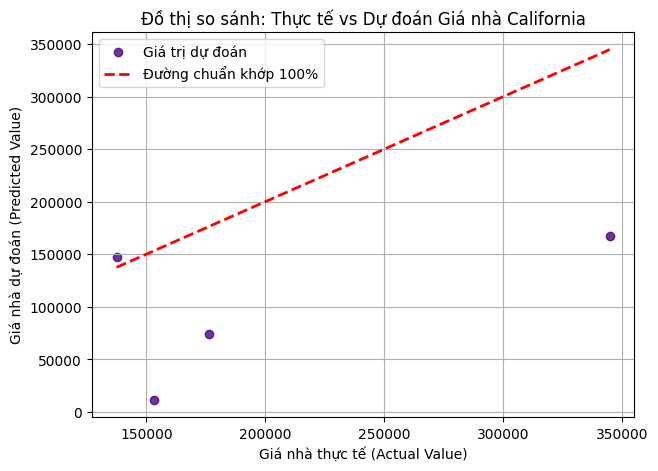

In [13]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for features, targets in val_loader:
        preds = model(features)
        all_preds.extend(preds.numpy())
        all_targets.extend(targets.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Tính toán các chỉ số lỗi hình thức
mae = np.mean(np.abs(all_preds - all_targets))
rmse = np.sqrt(np.mean((all_preds - all_targets) ** 2))

print("\n================ KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ================")
print(f"MAE (Sai số tuyệt đối trung bình): {mae:.2f} USD")
print(f"RMSE (Căn sai số bình phương trung bình): {rmse:.2f} USD")
print("=========================================================\n")

# --- Vẽ đồ thị so sánh ---
plt.figure(figsize=(7, 5))
plt.scatter(all_targets, all_preds, color='indigo', alpha=0.8, label='Giá trị dự đoán')
plt.plot([all_targets.min(), all_targets.max()], [all_targets.min(), all_targets.max()], 'r--', lw=2, label='Đường chuẩn khớp 100%')
plt.xlabel('Giá nhà thực tế (Actual Value)')
plt.ylabel('Giá nhà dự đoán (Predicted Value)')
plt.title('Đồ thị so sánh: Thực tế vs Dự đoán Giá nhà California')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# ==========================================
# 1. ĐỌC DỮ LIỆU TỪ GITHUB URL (Chỗ này mới là đọc data!)
# ==========================================
# Đường dẫn lấy file dữ liệu thô (Raw) từ GitHub của bạn
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/refs/heads/main/Data/babies.txt"

# Lệnh đọc dữ liệu: Do file .txt phân tách bằng các khoảng trắng (khoảng trống/tab),
# nên ta dùng cấu trúc sep=r'\s+' để Pandas tự động chia cột một cách chính xác.
df = pd.read_csv(url, sep=r'\s+')

print("ℹ️ Đọc thành công dữ liệu babies.txt từ GitHub!")
print("5 dòng đầu tiên của dữ liệu:")
print(df.head())

ℹ️ Đọc thành công dữ liệu babies.txt từ GitHub!
5 dòng đầu tiên của dữ liệu:
   bwt  smoke
0  120      0
1  113      0
2  128      1
3  123      0
4  108      1


--- THÔNG TIN DỮ LIỆU THÔ BAN ĐẦU ---
Tổng số dòng ban đầu: 1236
   bwt  smoke
0  120      0
1  113      0
2  128      1
3  123      0
4  108      1

--- THÔNG TIN DỮ LIỆU SAU KHI LÀM SẠCH ---
Tổng số dòng sau khi làm sạch: 1226

--- BẮT ĐẦU TIẾN TRÌNH HUẤN LUYỆN MÔ HÌNH ---
Epoch [15/150] -> Loss (MSE) trung bình: 12114.9560
Epoch [30/150] -> Loss (MSE) trung bình: 9766.5115
Epoch [45/150] -> Loss (MSE) trung bình: 7809.4306
Epoch [60/150] -> Loss (MSE) trung bình: 6193.8970
Epoch [75/150] -> Loss (MSE) trung bình: 4886.4239
Epoch [90/150] -> Loss (MSE) trung bình: 3854.1151
Epoch [105/150] -> Loss (MSE) trung bình: 3063.8900
Epoch [120/150] -> Loss (MSE) trung bình: 2466.6856
Epoch [135/150] -> Loss (MSE) trung bình: 1995.8600
Epoch [150/150] -> Loss (MSE) trung bình: 1595.0936

================ KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG ================
Chỉ số MAE (Sai số tuyệt đối trung bình): 32.3491
Chỉ số MSE (Sai số bình phương trung bình): 1467.0355
Chỉ số RMSE (Căn bậc hai của MSE): 38.3019


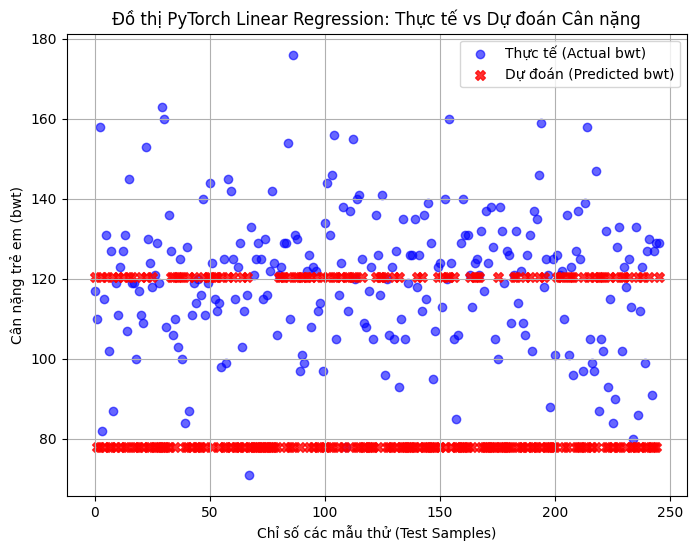

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# =====================================================================
# BƯỚC 1: ĐỌC DỮ LIỆU TỪ GITHUB URL (Data Loading)
# =====================================================================
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/babies.txt"
df = pd.read_csv(url, sep=r'\s+')

print("--- THÔNG TIN DỮ LIỆU THÔ BAN ĐẦU ---")
print(f"Tổng số dòng ban đầu: {len(df)}")
print(df.head())

# =====================================================================
# BƯỚC 2: LÀM SẠCH DỮ LIỆU (Data Cleaning)
# =====================================================================
# Trong bộ dữ liệu babies, giá trị smoke = 9 đại diện cho dữ liệu khuyết (Unknown)
# Tiến hành thay thế số 9 thành NaN và xóa bỏ hàng lỗi
df['smoke'] = df['smoke'].replace(9, np.nan)

# Loại bỏ tất cả các dòng chứa giá trị rỗng ở 2 cột bwt và smoke
df = df.dropna(subset=['bwt', 'smoke'])

print("\n--- THÔNG TIN DỮ LIỆU SAU KHI LÀM SẠCH ---")
print(f"Tổng số dòng sau khi làm sạch: {len(df)}")

# =====================================================================
# BƯỚC 3: PHÂN CHIA VÀ CHUẨN HÓA DỮ LIỆU CHỐNG LEAK (Pipeline Chuẩn)
# =====================================================================
# Nhãn mục tiêu cần dự đoán (y): Cân nặng trẻ em 'bwt'
y = df['bwt'].values.astype(np.float32)

# Đặc trưng đầu vào (X): Chỉ lấy cột 'smoke' vì dữ liệu thực tế chỉ có cột này
X = df[['smoke']].values.astype(np.float32)

# 🌟 QUY TẮC VÀNG: Chia tách dữ liệu Train/Test TRƯỚC KHI xử lý để tránh rò rỉ dữ liệu (Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuyển đổi dữ liệu trực tiếp sang PyTorch Tensors
# (Vì 'smoke' chỉ gồm giá trị 0 và 1 nên không cần StandardScaler để tránh làm mất ý nghĩa biến phân loại)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# =====================================================================
# BƯỚC 4: ĐÓNG GÓI VÀO DATALOADER (Quản lý Mini-batch)
# =====================================================================
# Đóng gói dữ liệu thành các batch nhỏ size = 16 theo đúng slide hướng dẫn
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# =====================================================================
# BƯỚC 5: ĐỊNH NGHĨA KIẾN TRÚC MÔ HÌNH LINEAR REGRESSION (nn.Module)
# =====================================================================
class PyTorchLinearRegression(nn.Module):
    def __init__(self, input_dim: int) -> None:
        super().__init__()
        # Khởi tạo lớp tuyến tính tính toán w*x + b
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        # Ép kích thước đầu ra từ [batch_size, 1] về [batch_size] để khớp với nhãn y
        return self.linear(x).squeeze(-1)

# Số lượng đặc trưng đầu vào = 1 (chỉ có cột smoke)
input_dim = X_train_tensor.shape[1]
model = PyTorchLinearRegression(input_dim)

# Thiết lập Hàm tính độ lỗi (Loss Function) và Bộ tối ưu hóa (Optimizer)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# =====================================================================
# BƯỚC 6: VÒNG LẶP HUẤN LUYỆN MÔ HÌNH (Training Loop)
# =====================================================================
epochs = 150
print("\n--- BẮT ĐẦU TIẾN TRÌNH HUẤN LUYỆN MÔ HÌNH ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch_features, batch_targets in train_loader:
        # 1. Xóa sạch đạo hàm tính toán của batch trước đó
        optimizer.zero_grad()

        # 2. Forward pass: Dự đoán kết quả từ đặc trưng đầu vào
        predictions = model(batch_features)

        # 3. Tính toán độ lỗi (Loss)
        loss = criterion(predictions, batch_targets)

        # 4. Backward pass: Lan truyền ngược tính đạo hàm tự động
        loss.backward()

        # 5. Cập nhật trọng số w và bias b
        optimizer.step()

        running_loss += loss.item() * batch_features.size(0)

    # In thông tin kiểm tra sau mỗi 15 epoch
    if (epoch + 1) % 15 == 0:
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}] -> Loss (MSE) trung bình: {epoch_loss:.4f}")

# =====================================================================
# BƯỚC 7: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP KIỂM THỬ ĐỘC LẬP (Evaluation)
# =====================================================================
model.eval()
all_predictions = []
all_targets = []

# Khóa gradient bằng torch.no_grad() khi đánh giá mô hình
with torch.no_grad():
    for batch_features, batch_targets in test_loader:
        preds = model(batch_features)
        all_predictions.extend(preds.numpy())
        all_targets.extend(batch_targets.numpy())

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

# Tính toán các chỉ số lỗi
mae = np.mean(np.abs(all_predictions - all_targets))
mse = np.mean((all_predictions - all_targets) ** 2)
rmse = np.sqrt(mse)

print("\n================ KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG ================")
print(f"Chỉ số MAE (Sai số tuyệt đối trung bình): {mae:.4f}")
print(f"Chỉ số MSE (Sai số bình phương trung bình): {mse:.4f}")
print(f"Chỉ số RMSE (Căn bậc hai của MSE): {rmse:.4f}")
print("============================================================\n")

# --- TRỰC QUAN HÓA KẾT QUẢ: ĐỒ THỊ SO SÁNH PREDICTED VS ACTUAL ---
plt.figure(figsize=(8, 6))
plt.scatter(range(len(all_targets)), all_targets, alpha=0.6, color='blue', label='Thực tế (Actual bwt)')
plt.scatter(range(len(all_predictions)), all_predictions, alpha=0.8, color='red', marker='X', s=50, label='Dự đoán (Predicted bwt)')
plt.ylabel('Cân nặng trẻ em (bwt)')
plt.xlabel('Chỉ số các mẫu thử (Test Samples)')
plt.title('Đồ thị PyTorch Linear Regression: Thực tế vs Dự đoán Cân nặng')
plt.legend()
plt.grid(True)
plt.show()

--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ---
Epoch [10/100] -> Train Loss: 3945.9258 | Val Loss: 3658.4395
Epoch [20/100] -> Train Loss: 1482.6096 | Val Loss: 1297.9102
Epoch [30/100] -> Train Loss: 687.9012 | Val Loss: 563.6718
Epoch [40/100] -> Train Loss: 396.1562 | Val Loss: 325.6281
Epoch [50/100] -> Train Loss: 327.5583 | Val Loss: 284.4273
Epoch [60/100] -> Train Loss: 318.9462 | Val Loss: 286.8999
Epoch [70/100] -> Train Loss: 318.3410 | Val Loss: 288.7912
Epoch [80/100] -> Train Loss: 318.3021 | Val Loss: 289.6485
Epoch [90/100] -> Train Loss: 319.0841 | Val Loss: 288.8030
Epoch [100/100] -> Train Loss: 318.7338 | Val Loss: 288.8228


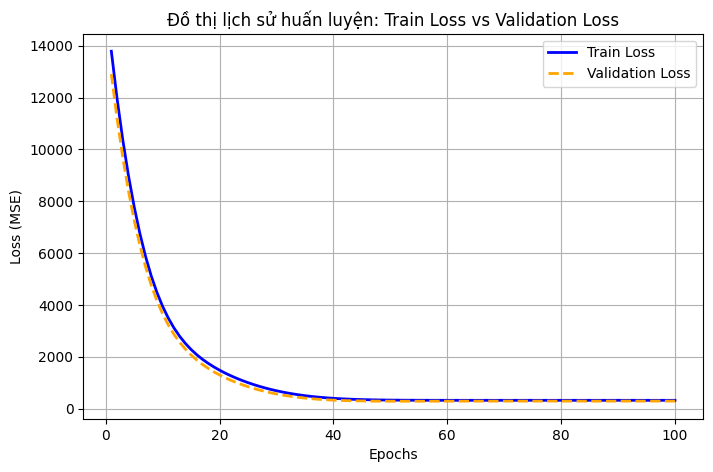

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# =====================================================================
# BƯỚC 1: ĐỌC DỮ LIỆU TỪ GITHUB URL
# =====================================================================
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/babies.txt"
df = pd.read_csv(url, sep=r'\s+')

# =====================================================================
# BƯỚC 2: LÀM SẠCH DỮ LIỆU (Data Cleaning)
# =====================================================================
# Loại bỏ các giá trị khuyết (quy ước số 9 trong cột smoke là Unknown)
df['smoke'] = df['smoke'].replace(9, np.nan)
df = df.dropna(subset=['bwt', 'smoke'])

# =====================================================================
# BƯỚC 3: PHÂN CHIA DỮ LIỆU CHỐNG LEAK (The Proper Way to Normalize)
# =====================================================================
y = df['bwt'].values.astype(np.float32)
X = df[['smoke']].values.astype(np.float32)

# Chia tách Train/Test trước khi đưa vào huấn luyện
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuyển đổi sang PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# =====================================================================
# BƯỚC 4: ĐÓNG GÓI VÀO DATALOADER
# =====================================================================
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# =====================================================================
# BƯỚC 5: ĐỊNH NGHĨA MÔ HÌNH LINEAR REGRESSION
# =====================================================================
class PyTorchLinearRegression(nn.Module):
    def __init__(self, input_dim: int) -> None:
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze(-1)

input_dim = X_train_tensor.shape[1]
model = PyTorchLinearRegression(input_dim)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1) # Dùng LR lớn hơn một chút để thấy loss giảm rõ rệt

# =====================================================================
# BƯỚC 6: VÒNG LẶP HUẤN LUYỆN & LƯU LẠI LỊCH SỬ LOSS
# =====================================================================
epochs = 100
train_loss_history = []
val_loss_history = []

print("--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ---")
for epoch in range(epochs):
    # Trạng thái Huấn luyện (Train)
    model.train()
    running_train_loss = 0.0
    for batch_features, batch_targets in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_features)
        loss = criterion(predictions, batch_targets)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * batch_features.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_loss_history.append(epoch_train_loss)

    # Trạng thái Đánh giá trên tập Validation/Test (Evaluation)
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_features, batch_targets in test_loader:
            preds = model(batch_features)
            val_loss = criterion(preds, batch_targets)
            running_val_loss += val_loss.item() * batch_features.size(0)

    epoch_val_loss = running_val_loss / len(test_loader.dataset)
    val_loss_history.append(epoch_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

# =====================================================================
# BƯỚC 7: VẼ ĐỒ THỊ LOSS CURVE (Đúng chuẩn yêu cầu đồ thị bài học)
# =====================================================================
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label='Train Loss', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), val_loss_history, label='Validation Loss', color='orange', linestyle='--', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Đồ thị lịch sử huấn luyện: Train Loss vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# ① Đọc dữ liệu từ GitHub
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/babies.txt"
df = pd.read_csv(url, sep=r'\s+')

# ② Làm sạch dữ liệu (Xóa bỏ các dòng chứa giá trị lỗi số 9 trong cột smoke)
df['smoke'] = df['smoke'].replace(9, np.nan)
df = df.dropna(subset=['bwt', 'smoke'])

# ③ Trích xuất X (Đặc trưng) và y (Nhãn mục tiêu)
X = df[['smoke']].values.astype(np.float32)
y = df['bwt'].values.astype(np.float32)

# ④ Quy tắc vàng: Chia tập Train (80%) và tập Validation (20%) trước khi huấn luyện
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# ⑤ Chuyển sang PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# ⑥ Đóng gói vào DataLoader quản lý Mini-batch (Kích thước nhóm = 16)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"✔️ Chuẩn bị dữ liệu ANN thành công! Số lượng mẫu Train: {len(X_train)}")

✔️ Chuẩn bị dữ liệu ANN thành công! Số lượng mẫu Train: 980


In [25]:
class CaliforniaBabiesANN(nn.Module):
    def __init__(self, input_dim: int) -> None:
        super().__init__()
        # Kiến trúc 3 tầng: Input (input_dim) -> Hidden (32 nơ-ron) -> Output (1 nơ-ron)
        self.hidden_layer = nn.Linear(input_dim, 32) # Tầng ẩn chứa 32 nơ-ron liên kết fully connected
        self.activation = nn.ReLU()                  # Hàm kích hoạt phi tuyến ReLU chống bão hòa đạo hàm
        self.output_layer = nn.Linear(32, 1)          # Tầng đầu ra đưa về 1 giá trị cân nặng liên tục

    def forward(self, x):
        # Lan truyền tiến (Forward Pass)
        x = self.hidden_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x.squeeze(-1) # Ép shape tensor từ [batch, 1] về [batch]

# Khởi tạo mô hình mạng ANN
input_dim = X_train_tensor.shape[1] # input_dim = 1 (cột smoke)
model = CaliforniaBabiesANN(input_dim)

# Định nghĩa hàm Loss function và Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01) # Sử dụng bộ tối ưu Adam giúp mạng cập nhật trọng số mượt mà

In [26]:
epochs = 150
train_loss_history = []
val_loss_history = []

print("--- TIẾN HÀNH HUẤN LUYỆN MẠNG NƠ-RON (ANN) ---")
for epoch in range(epochs):
    # LẬP TRÌNH TRẠNG THÁI HỌC (TRAIN)
    model.train()
    running_train_loss = 0.0
    for batch_features, batch_targets in train_loader:
        optimizer.zero_grad()               # 1. Xóa gradient batch cũ
        preds = model(batch_features)        # 2. Dự đoán đầu ra
        loss = criterion(preds, batch_targets) # 3. Tính độ lỗi MSE
        loss.backward()                     # 4. Lan truyền ngược tính đạo hàm
        optimizer.step()                    # 5. Cập nhật trọng số mạng
        running_train_loss += loss.item() * batch_features.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_loss_history.append(epoch_train_loss)

    # LẬP TRÌNH TRẠNG THÁI ĐÁNH GIÁ (EVALUATION)
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad(): # Tắt tính đạo hàm tự động để tiết kiệm bộ nhớ RAM
        for batch_features, batch_targets in val_loader:
            preds = model(batch_features)
            val_loss = criterion(preds, batch_targets)
            running_val_loss += val_loss.item() * batch_features.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_loss_history.append(epoch_val_loss)

    # In tiến trình ra màn hình sau mỗi 15 epoch
    if (epoch + 1) % 15 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {epoch_train_loss:.4f} | Validation Loss: {epoch_val_loss:.4f}")

--- TIẾN HÀNH HUẤN LUYỆN MẠNG NƠ-RON (ANN) ---
Epoch [15/150] -> Train Loss: 318.6637 | Validation Loss: 289.8560
Epoch [30/150] -> Train Loss: 319.5642 | Validation Loss: 292.5323
Epoch [45/150] -> Train Loss: 321.8600 | Validation Loss: 291.9249
Epoch [60/150] -> Train Loss: 322.1066 | Validation Loss: 287.0452
Epoch [75/150] -> Train Loss: 320.0132 | Validation Loss: 292.9024
Epoch [90/150] -> Train Loss: 322.0274 | Validation Loss: 292.5543
Epoch [105/150] -> Train Loss: 319.6091 | Validation Loss: 288.3048
Epoch [120/150] -> Train Loss: 321.8119 | Validation Loss: 294.4336
Epoch [135/150] -> Train Loss: 320.4387 | Validation Loss: 291.7932
Epoch [150/150] -> Train Loss: 323.7974 | Validation Loss: 289.6870


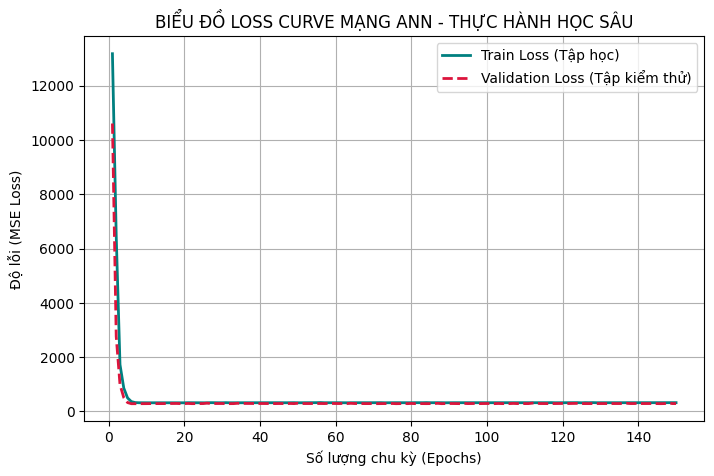


================ KẾT QUẢ SÁT HẠCH MẠNG ANN ================
Sai số tuyệt đối trung bình (MAE): 13.0658
Sai số RMSE của mô hình: 17.0202


In [28]:
# Vẽ đồ thị Loss Curve theo yêu cầu bài học
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label='Train Loss (Tập học)', color='teal', linewidth=2)
plt.plot(range(1, epochs + 1), val_loss_history, label='Validation Loss (Tập kiểm thử)', color='crimson', linestyle='--', linewidth=2)
plt.xlabel('Số lượng chu kỳ (Epochs)')
plt.ylabel('Độ lỗi (MSE Loss)')
plt.title('BIỂU ĐỒ LOSS CURVE MẠNG ANN - THỰC HÀNH HỌC SÂU')
plt.legend()
plt.grid(True)
plt.show()

# Đánh giá các chỉ số metrics cuối cùng
model.eval()
with torch.no_grad():
    val_preds = model(X_val_tensor).numpy()
    val_targets = y_val_tensor.numpy()

mae = np.mean(np.abs(val_preds - val_targets))
rmse = np.sqrt(np.mean((val_preds - val_targets) ** 2))

print("\n================ KẾT QUẢ SÁT HẠCH MẠNG ANN ================")
print(f"Sai số tuyệt đối trung bình (MAE): {mae:.4f}")
print(f"Sai số RMSE của mô hình: {rmse:.4f}")
print("===========================================================")